Tarefa: Série temporal da poluição na China
Olá!

No exemplo sobre a previsão dos valores das ações, nós trabalhamos com uma série temporal que apresenta os valores dia a dia. Porém, também podemos utilizar outros formatos de data, como por exemplo: horas, minutos ou segundos (dependendo do contexto). A base de dados desta tarefa possui essas características, na qual temos em cada registro o ano, o mês, o dia e a hora juntamente com o valor de poluição naquele momento e algumas características climáticas. Na imagem abaixo você pode visualizar alguns registros


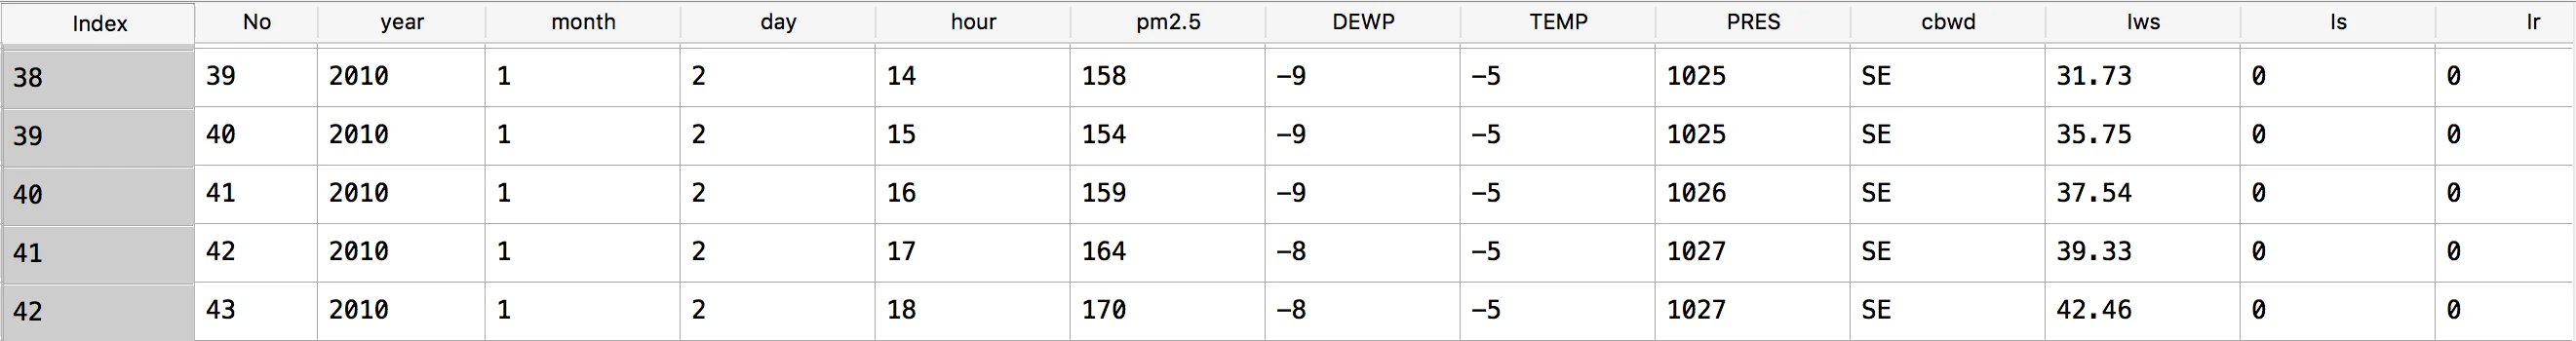


O atributo No é somente a contagem de registros (como uma chave primária), o year , month , day e hour indicam a dimensão temporal (de hora em hora); o atributo pm2.5 diz respeito ao nível de poluição (que faremos a previsão) e por fim, todos os outros atributos serão os previsores. Baseado nos atributos previsores, a ideia é indicar o nível de poluição em uma determinada hora.

Siga as seguintes dicas para essa atividade:

Use a função dropna() para excluir valores faltantes

Os atributos No , year , month , day , hour e cbwd devem ser excluídos, pois em uma série temporal essas informações não são importantes (o cbwd é somente um campo string)

Este é um problema com uma única saída (pm2.5 ) e múltiplos previsores

- testar com vários valores de intervalos de tempo (começando com 10, por exemplo)

- optar por dividir a base de dados entre treinamento e teste ou usar a própria base de dados de treinamento (em nossa implementação usamos a própria base de treinamento)

- Depois de treinar a rede neural, gere o gráfico para visualizar os resultados das previsões. Abaixo você pode visualizar o gráfico com os nossos resultados


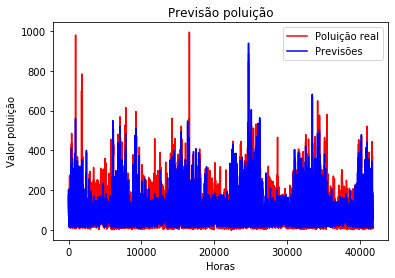


In [1]:
# ambiente anaconda
import sys
print(sys.executable) # orange3 ou youtube
import sys
print(sys.version)

/home/fabiene/anaconda3/envs/orange3/bin/python
3.10.18 (main, Jun  5 2025, 13:14:17) [GCC 11.2.0]


# Tarefa: Série temporal da poluição na China

## Etapa 1: Importação das bibliotecas

In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import torch
from torch import nn, optim
from sklearn.metrics import mean_absolute_error
torch.__version__

'2.9.1+cpu'

In [3]:
torch.manual_seed(123) # semente

## Etapa 2: Base de dados

- Cada registro representa o nível de poluição em cada hora (medida de hora em hora)
- A ideia é prever o nível de poluição em uma determinada hora baseado nas horas anteriores


In [4]:
base = pd.read_csv('poluicao.csv')

In [5]:
base.head()

,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir
0,1,2010,1,1,0,NaN,-21,-11.0,1021.0,NW,1.79,0,0
1,2,2010,1,1,1,NaN,-21,-12.0,1020.0,NW,4.92,0,0
2,3,2010,1,1,2,NaN,-21,-11.0,1019.0,NW,6.71,0,0
3,4,2010,1,1,3,NaN,-21,-14.0,1019.0,NW,9.84,0,0
4,5,2010,1,1,4,NaN,-20,-12.0,1018.0,NW,12.97,0,0


In [6]:
base.shape

(43824, 13)

In [7]:
print(base.isnull().sum())

No          0
year        0
month       0
day         0
hour        0
pm2.5    2067
DEWP        0
TEMP        0
PRES        0
cbwd        0
Iws         0
Is          0
Ir          0
dtype: int64


In [8]:
base = base.dropna()

In [9]:
print(base.isnull().sum())

No       0
year     0
month    0
day      0
hour     0
pm2.5    0
DEWP     0
TEMP     0
PRES     0
cbwd     0
Iws      0
Is       0
Ir       0
dtype: int64


In [10]:
base.shape

(41757, 13)

In [11]:
# Exclusão de atributos que não serão utilizados para a análise
# "No" é o número do registro
# "Year", "month", "day" e "hour" são as informações temporais que não são utilizadas para análise
# "Cbwd" é um atributo de texto que não está relacionado com as previsões
base = base.drop('No', axis = 1)
base = base.drop('year', axis = 1)
base = base.drop('month', axis = 1)
base = base.drop('day', axis = 1)
base = base.drop('hour', axis = 1)
base = base.drop('cbwd', axis = 1)

In [12]:
base.tail()

,pm2.5,DEWP,TEMP,PRES,Iws,Is,Ir
43819,8.0,-23,-2.0,1034.0,231.97,0,0
43820,10.0,-22,-3.0,1034.0,237.78,0,0
43821,10.0,-22,-3.0,1034.0,242.70,0,0
43822,8.0,-22,-4.0,1034.0,246.72,0,0
43823,12.0,-21,-3.0,1034.0,249.85,0,0


In [13]:
base_treinamento = base.values

In [14]:
base_treinamento

array([[129.  , -16.  ,  -4.  , ...,   1.79,   0.  ,   0.  ],
       [148.  , -15.  ,  -4.  , ...,   2.68,   0.  ,   0.  ],
       [159.  , -11.  ,  -5.  , ...,   3.57,   0.  ,   0.  ],
       ...,
       [ 10.  , -22.  ,  -3.  , ..., 242.7 ,   0.  ,   0.  ],
       [  8.  , -22.  ,  -4.  , ..., 246.72,   0.  ,   0.  ],
       [ 12.  , -21.  ,  -3.  , ..., 249.85,   0.  ,   0.  ]])

In [15]:
base.columns[0]

'pm2.5'

In [16]:
base.columns

Index(['pm2.5', 'DEWP', 'TEMP', 'PRES', 'Iws', 'Is', 'Ir'], dtype='object')

In [17]:
# 1. Seleção da Coluna (fatiamento):
# 'base_treinamento[:, 0]' acessa todas as linhas (:) da primeira coluna (índice 0).
# Se a sua base tem (pm2.5', 'DEWP', 'TEMP', 'PRES', 'Iws', 'Is', 'Ir'), o índice 0 pega apenas o 'Open'.
# O resultado disso é uma "lista simples" (vetor unidimensional).
poluicao = base_treinamento[:, 0]

# 2. Redimensionamento (.reshape(-1, 1)):
# O '-1' diz ao Python: "Mantenha o número de linhas que já existe".
# O '1' diz: "Organize esses dados em exatamente 1 coluna vertical".
# Isso transforma o vetor (ex: [10, 20, 30]) em uma matriz (ex: [[10], [20], [30]]).
# É OBRIGATÓRIO fazer isso para poder usar o MinMaxScaler() depois.
poluicao = poluicao.reshape(-1, 1)

#poluicao = base_treinamento[:, 0].reshape(-1, 1)

In [18]:
# 1. Configura o Normalizador (Escalonador):
# O MinMaxScaler é uma ferramenta que "achata" os dados. 
# O 'feature_range = (0, 1)' define que o menor pm2.5 da base será 0, 
# o maior será 1, e todos os outros serão transformados em decimais entre eles.
normalizador = MinMaxScaler(feature_range = (0, 1))

# 2. Aprende e Transforma (fit_transform):
# Esta linha faz o trabalho pesado:
# - 'fit': Analisa a 'base_treinamento' para descobrir o valor Mínimo e o Máximo.
# - 'transform': Aplica a fórmula matemática em cada linha da base.
# O resultado (pm2.5 convertidos) é salvo na variável 'base_treinamento_normalizada'.
base_treinamento_normalizada = normalizador.fit_transform(base_treinamento)

In [19]:
base.columns[1:7]

Index(['DEWP', 'TEMP', 'PRES', 'Iws', 'Is', 'Ir'], dtype='object')

In [20]:
base.columns[0]

'pm2.5'

In [21]:
len(base_treinamento_normalizada)

41757

In [22]:
# Criação da estrutura de dados que representa a série temporal, considerando
# 10 horas anteriores para prever a hora atual

# 1. Inicializa as listas de Entrada (X) e Saída (y):
# X guardará as "fotos" do passado (as 10 horas anteriores). 'DEWP', 'TEMP', 'PRES', 'Iws', 'Is', 'Ir'
# y guardará o "alvo" (o nível de poluição que queremos adivinhar). 'pm2.5'
X = []
y = []

# 2. Loop de Janela Deslizante (Sliding Window):
# Começamos em 10 porque precisamos de 10 horas de histórico para a primeira previsão.
# O 41757 é o limite final de linhas da sua base de treinamento.
for i in range(10, 41757):
    # X: Pega as 10 horas anteriores (i-10 até i).
    # [:, 1:7] seleciona as colunas de 1 a 6 (Ex: Clima, Vento, Umidade, etc).
    # Esses são os nossos "Previsores" (Features).
    X.append(base_treinamento_normalizada[i-10:i, 1:7]) # os previsores estão nas colunas 1 a 6
    
    # y: Pega o valor real da hora atual (índice i).
    # [:, 0] seleciona apenas a coluna 0 (Nível de Poluição PM2.5).
    # Este é o nosso "Alvo" (Label).
    y.append(base_treinamento_normalizada[i, 0]) # o valor a ser previsto (poluição) está na coluna 0

# 3. Conversão para Arrays do NumPy:
# Transforma as listas de Python em matrizes numéricas de alta performance.
# O X agora terá o formato (41747, 10, 6) -> (Amostras, Janela de Tempo, Características).
X, y = np.array(X), np.array(y)

In [23]:
# 1. Converte os dados para Tensores do PyTorch:
# O comando 'torch.tensor' transforma os arrays do NumPy em objetos do tipo Tensor.
# Diferente de uma lista comum, um Tensor é uma estrutura matemática que o PyTorch 
# consegue usar para calcular derivadas (gradientes) e otimizar os pesos da rede.

# 2. Define a precisão dos dados (dtype = torch.float32):
# O 'float32' (ponto flutuante de 32 bits) é o padrão ouro para Redes Neurais.
# Ele oferece o equilíbrio perfeito entre precisão e velocidade. 
# Usar float64 (padrão do NumPy) deixaria o treino muito lento e ocuparia o dobro de memória.

# 3. Preparação Final:
# Agora, 'X' e 'y' estão prontos para serem entregues ao modelo.
# Sem essa conversão, se você tentasse passar os dados para a rede, 
# o Python retornaria um erro dizendo que "não sabe processar numpy.ndarray".
X = torch.tensor(X, dtype = torch.float32)
y = torch.tensor(y, dtype = torch.float32)

In [24]:
# 1. Criação do Conjunto de Dados (TensorDataset):
# O TensorDataset agrupa os seus previsores (X) e os seus alvos (y) em um único objeto.
# Ele garante que o X[0] esteja sempre vinculado ao y[0], o X[1] ao y[1], e assim por diante.
# É como se estivesse grampeando a "pergunta" (X) na "resposta" (y).
dataset = torch.utils.data.TensorDataset(X, y)

# 2. Configuração do Carregador de Dados (DataLoader):
# O DataLoader é o "motor" que vai alimentar a rede neural durante o treino.
# - batch_size = 64: Em vez de mostrar os 40.000 dados de uma vez (o que travaria a memória),
#   o modelo olha para 64 exemplos por vez, ajusta os pesos e passa para os próximos 64.
# - shuffle = True: Embaralha os dados a cada nova época. Isso é CRUCIAL para que a rede
#   não decore a ordem das horas e aprenda de fato os padrões climáticos e de poluição.
loader = torch.utils.data.DataLoader(dataset, batch_size = 64, shuffle = True)

## Etapa 3: Construção da rede neural recorrente

In [25]:
class regressor_LSTM(nn.Module):
    def __init__(self):
        super().__init__()
        # O primeiro input_size é o número de dimensões que cada dado tem em cada timestep. 
        #Nesse caso, são 6 dimensões, uma para cada variável.

        # 1. Primeira Camada LSTM:
        # Recebe 6 variáveis (input_size=6) e expande para 100 neurônios internos.  'DEWP', 'TEMP', 'PRES', 'Iws', 'Is', 'Ir'
        # Ela começa a extrair as relações entre clima, vento e poluição. Temperatura, pressão, temperatura de orvalho.
        self.lstm1 = nn.LSTM(input_size = 6, hidden_size = 100)

        # 2. Segunda Camada LSTM:
        # Reduz de 100 para 50 neurônios, refinando as características aprendidas.
        self.lstm2 = nn.LSTM(100, 50)

        # 3. Terceira Camada LSTM (Empilhada):
        # 'num_layers = 2' cria duas subcamadas internas de 50 neurônios cada.
        # 'dropout = 0.3' ajuda a evitar que a rede decore os dados (overfitting).
        self.lstm3 = nn.LSTM(50, 50, dropout = 0.3, num_layers = 2)

        # 4. Camada de Dropout Extra:
        # Desliga aleatoriamente 30% dos neurônios durante o treino para tornar a rede robusta.
        self.dropout = nn.Dropout(p = 0.3)

        # 5. Camada Linear (Saída):
        # Pega os 50 sinais finais e os transforma em apenas 1 valor: a Previsão da Poluição.
        self.linear = nn.Linear(in_features = 50, out_features = 1) # previsão pm2.5

    def forward(self, X):
        # Como o método vai receber os atributos previsores no formato (`batch` [posição 0], 
        #`n_timesteps` [1], `dimensions` [2]), vou usar o método permute para mudar 
        #as dimensões para o formato necessário (`n_timesteps` [posição original 1], `batch` [0], `dimensions´ [2]).

        # Ajuste de Dimensão (Permute):
        # O PyTorch espera as sequências no formato (Tempo, Lote, Variáveis).
        # Como nosso DataLoader entrega (Lote, Tempo, Variáveis), o permute resolve isso.
        X = X.permute(1, 0, 2)
        
        # Cada camada LSTM produz um output (contendo as saídas para todos os timesteps) 
        #e um tuple contendo o estado da camada oculta e da célula. 
        #Como não vamos reciclar os valroes da camada oculta e da célula, estou descartando eles.
        
        # Fluxo dos Dados pelas LSTMs:
        # O '_' ignora os estados internos (hidden/cell state) que não usaremos agora.
        X, _ = self.lstm1(X)
        X = self.dropout(X)
        
        X, _ = self.lstm2(X)
        X = self.dropout(X)
        
        X, _ = self.lstm3(X)
        
        # Pega apenas a saída do ÚLTIMO timestep da sequência para fazer a previsão
        #X = X[-1] # sugestão não deu certo. ideia por fora
        # Seleciona o último estado (o "agora") para todo o lote
        #X = X[-1, :, :]
        
        X = self.dropout(X)
        
        # Camada final que entrega o valor numérico da poluição
        X = self.linear(X)

        return X

In [26]:
# Verifica se existe uma GPU da NVIDIA configurada (CUDA).
# Se o computador tiver uma placa de vídeo compatível, o 'device' será 'cuda'.
# Caso contrário, ele usará o processador comum ('cpu').
# Nota: Treinar LSTMs em GPU é drasticamente mais rápido do que em CPU.
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

# Exibe qual hardware foi selecionado para confirmar antes de iniciar o treino.
device

device(type='cpu')

In [27]:
# 1. Instancia o Modelo: 
# Cria o objeto 'regressor' baseado na classe regressor_LSTM que você definiu. 
# Neste momento, o PyTorch reserva espaço na memória e inicializa os pesos dos neurônios.
regressor = regressor_LSTM()

# 2. Define a Função de Perda (Criterion):
# O MSELoss (Erro Quadrático Médio) é a métrica que diz quão longe a rede está da realidade.
# Ele calcula a diferença entre a poluição prevista e a real, elevando ao quadrado.
# Isso faz com que erros grandes sejam "punidos" com muito mais peso que erros pequenos.
criterion = nn.MSELoss()

# 3. Define o Otimizador (Adam):
# O Adam é o algoritmo que ajusta os pesos (parâmetros) da rede para diminuir o erro.
# - regressor.parameters(): Indica ao Adam quais "botões" (pesos) ele pode girar.
# - O Adam é muito popular porque ajusta a taxa de aprendizado sozinho durante o treino,
#   sendo excelente para lidar com ruídos em séries temporais de poluição.
optimizer = optim.Adam(regressor.parameters())

In [28]:
regressor.to(device)

regressor_LSTM(
  (lstm1): LSTM(6, 100)
  (lstm2): LSTM(100, 50)
  (lstm3): LSTM(50, 50, num_layers=2, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (linear): Linear(in_features=50, out_features=1, bias=True)
)

## Etapa 4: Treinamento do modelo

In [29]:
# Listas para armazenar o histórico e permitir a plotagem do gráfico depois
historico_loss = []
historico_mae = []


# Inicia o treinamento por 100 épocas (100 passagens completas pelo dataset)
for epoch in range(100):
    # Reinicia os acumuladores de erro (Loss e MAE) no começo de cada época
    running_loss = 0.
    running_mae = 0.

    # Percorre os "pacotes" (batches) de 64 horas entregues pelo DataLoader
    for i, data in enumerate(loader):
        # Desempacota os dados (inputs = 10h passadas, labels = poluição real atual)
        inputs, labels = data
        
        # Envia os dados para a GPU ou CPU conforme definido anteriormente
        inputs, labels = inputs.to(device), labels.to(device)

        # PASSO 1: Limpa os gradientes acumulados da rodada anterior
        optimizer.zero_grad()

        # PASSO 2: O modelo faz a previsão baseada nas 10h de histórico
        outputs = regressor(inputs)
        
        # *Cada output contém previsões para os 10 timesteps (entre t = 1 e t = 11), nós só precisamos do último valor
        # Filtra apenas o ÚLTIMO valor da sequência (o tempo t=11 que queremos prever)
        outputs = outputs[-1]
        
        # *Pra não ocasionar erro na hora de computador o custo, é melhor deixar os outputs 
        # e as labels no mesmo formato. Essa é a forma mais fácil de fazer isso:
        # Ajusta o formato (shape) da previsão para ser idêntico ao da resposta real
        # Isso evita erros matemáticos na hora de calcular a distância entre eles
        outputs = outputs.view(*labels.shape)

        # PASSO 3: Calcula o erro (Custo) entre a previsão e a realidade
        loss = criterion(outputs, labels)
        
        # PASSO 4: Backpropagation - Calcula como cada peso contribuiu para o erro
        loss.backward()

        # PASSO 5: Atualiza os pesos dos neurônios usando o otimizador Adam
        optimizer.step()

        # Soma o valor do erro para monitorar a evolução
        running_loss += loss.item()
        
        # *Determinando MAE
        # Calcula o Erro Médio Absoluto (MAE) convertendo Tensores para NumPy
        # detach() remove do gráfico de treino e cpu() traz da GPU para a memória RAM
        mae = mean_absolute_error(labels.detach().cpu().numpy().flatten(), 
                                  outputs.detach().cpu().numpy().flatten())
        running_mae += mae


        
        # * Imprimindo os dados referentes a esse loop
        # Mostra o progresso em tempo real na mesma linha (\r)
        print('\rÉpoca {:3d} - Loop {:3d} de {:3d}: perda {:03.5f} - MAE {:03.5f}'.format(epoch + 1, i + 1, 
                                                                                          len(loader), 
                                                                                          loss, mae), end = '\r')  

    # Salva as médias nas listas de histórico para gerar o gráfico ao final
    historico_loss.append(running_loss)
    historico_mae.append(running_mae)
        
    # * Imprimindo os dados referentes a essa época
    # Ao final da época, calcula a média do custo e do erro e exibe o resumo
    print('\rÉPOCA {:3d} FINALIZADA: perda {:.5f} - MAE {:.5f}          '.format(epoch + 1, 
                                                                                 running_loss/len(loader), 
                                                                                 running_mae/len(loader))
         )

ÉPOCA   1 FINALIZADA: perda 0.00792 - MAE 0.06445          
ÉPOCA   2 FINALIZADA: perda 0.00633 - MAE 0.05662          
ÉPOCA   3 FINALIZADA: perda 0.00567 - MAE 0.05297          
ÉPOCA   4 FINALIZADA: perda 0.00541 - MAE 0.05143          
ÉPOCA   5 FINALIZADA: perda 0.00530 - MAE 0.05103          
ÉPOCA   6 FINALIZADA: perda 0.00523 - MAE 0.05058          
ÉPOCA   7 FINALIZADA: perda 0.00513 - MAE 0.05001          
ÉPOCA   8 FINALIZADA: perda 0.00508 - MAE 0.04986          
ÉPOCA   9 FINALIZADA: perda 0.00504 - MAE 0.04961          
ÉPOCA  10 FINALIZADA: perda 0.00498 - MAE 0.04920          
ÉPOCA  11 FINALIZADA: perda 0.00494 - MAE 0.04901          
ÉPOCA  12 FINALIZADA: perda 0.00490 - MAE 0.04882          
ÉPOCA  13 FINALIZADA: perda 0.00487 - MAE 0.04864          
ÉPOCA  14 FINALIZADA: perda 0.00481 - MAE 0.04832          
ÉPOCA  15 FINALIZADA: perda 0.00484 - MAE 0.04856          
ÉPOCA  16 FINALIZADA: perda 0.00480 - MAE 0.04822          
ÉPOCA  17 FINALIZADA: perda 0.00475 - MA

Curva de "L": Se as linhas descem rápido e depois ficam quase retas, parabéns! Seu modelo convergiu e aprendeu o máximo que podia com esses dados.

Linha "Serra": Se o gráfico sobe e desce muito bruscamente (instabilidade), talvez o seu lr (taxa de aprendizado) no RMSprop esteja alto demais.

Linha Reta (no topo): Se a linha não desce, o modelo não está aprendendo. Verifique se a normalização dos dados foi feita corretamente.

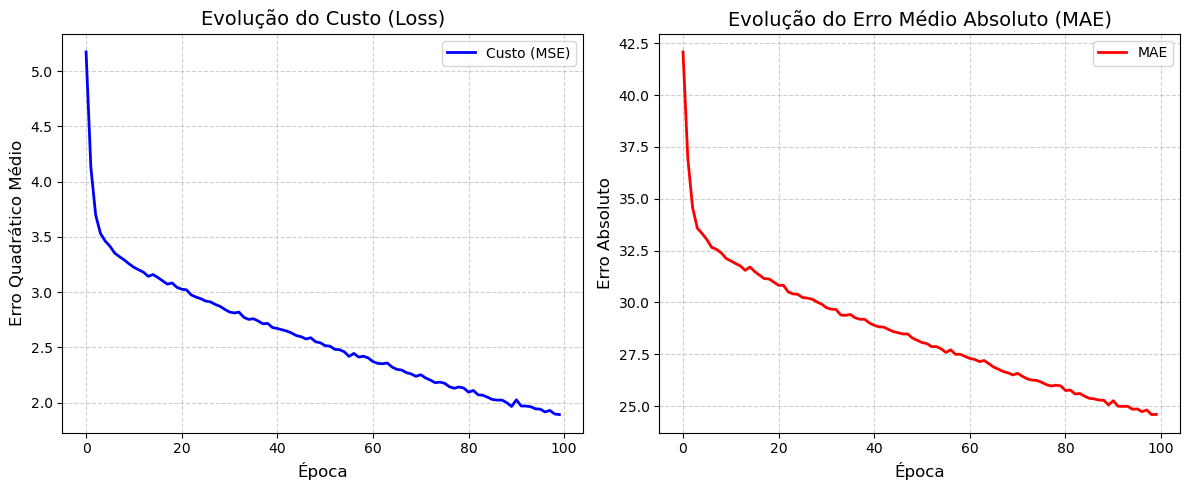

In [30]:
import matplotlib.pyplot as plt

# Define o tamanho da figura (largura, altura)
plt.figure(figsize=(12, 5))

# --- GRÁFICO 1: Custo (Loss/MSE) ---
# O MSE (Mean Squared Error) é a métrica que o otimizador usa para ajustar os pesos.
plt.subplot(1, 2, 1) # Cria o primeiro gráfico de uma grade 1x2
plt.plot(historico_loss, label='Custo (MSE)', color='blue', linewidth=2)
plt.title('Evolução do Custo (Loss)', fontsize=14)
plt.xlabel('Época', fontsize=12)
plt.ylabel('Erro Quadrático Médio', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6) # Adiciona uma grade leve para facilitar a leitura
plt.legend()

# --- GRÁFICO 2: Erro Médio Absoluto (MAE) ---
# O MAE mostra o erro médio na mesma unidade dos seus dados originais.
plt.subplot(1, 2, 2) # Cria o segundo gráfico
plt.plot(historico_mae, label='MAE', color='red', linewidth=2)
plt.title('Evolução do Erro Médio Absoluto (MAE)', fontsize=14)
plt.xlabel('Época', fontsize=12)
plt.ylabel('Erro Absoluto', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Ajusta o espaçamento entre os gráficos para não sobrepor os títulos
plt.tight_layout()
plt.show()

1. Evolução do Custo (Loss - Gráfico Azul)
2. 
Este gráfico mostra o resultado do seu criterion = nn.MSELoss().

O que ele mede: A distância entre o que a rede previu e o valor real, elevada ao quadrado.

O que o desenho diz: Note que a curva começa muito alta (perto de 5.0) e cai rapidamente nas primeiras épocas. Isso acontece porque, no começo, a rede estava dando "chutes" aleatórios.

Conclusão: Como a linha continua descendo de forma suave e constante até o final (chegando perto de 2.0), significa que o Otimizador Adam está conseguindo ajustar os pesos dos neurônios com sucesso. Não há sinais de travamento (platô).

2. Evolução do Erro Médio Absoluto (MAE - Gráfico Vermelho)
Este gráfico é mais fácil de entender em termos "reais".

O que ele mede: A média da diferença absoluta entre a previsão e a realidade. Diferente do azul, ele não eleva ao quadrado, então ele representa o erro "puro".

O que o desenho diz: Ele começou com um erro médio de 42 (um erro bem alto) e terminou abaixo de 25.

Conclusão: Isso mostra que, a cada época, a IA fica mais "precisa". O fato de as duas curvas (Azul e Vermelha) terem o mesmo formato indica que o modelo está estável.

🔍 O diagnóstico do modelo:

Os gráficos estão excelentes, mas com uma observação importante: a curva ainda está descendo no final (época 100). Isso sugere que:

O modelo não sofreu Overfitting (quando ele decora os dados e a curva começa a subir).

Se treinasse por mais 50 ou 100 épocas, o erro provavelmente cairia ainda mais, pois a linha ainda não "estacionou" (não virou uma linha horizontal).

## Etapa 5: Previsões

- Neste exemplo não utilizaremos uma base de dados específica para teste, ou seja, faremos as previsões diretamente na base de dados de treinamento


In [31]:
# 1. Coloca o modelo em modo de Avaliação (Teste):
# Isso é CRUCIAL! LSTMs e camadas de Dropout se comportam diferente no treino.
# O .eval() avisa ao PyTorch para:
# - Desativar o Dropout (queremos todos os neurônios trabalhando agora).
# - Ignorar o cálculo de gradientes (economiza muita memória e processamento).
regressor.eval()

# 2. Realiza a Previsão em todo o conjunto X:
# Aqui você entrega os dados de entrada (X) para o modelo.
# O '.to(device)' garante que os dados subam para a GPU (se disponível), 
# para que o cálculo seja feito na mesma "língua" que o modelo foi treinado.
# O resultado 'previsoes' será um Tensor com os valores de poluição estimados.
previsoes = regressor(X.to(device))

In [32]:
# O modelo retorna valores para todos os timesteps, 
# mas nós só estamos interessados no último timestep (t = 91), então vamos extrair o último valor.

# 1. Extração do último Timestep:
# Como a LSTM processa a sequência inteira, ela gera uma previsão para cada 
# hora/dia da janela. Como só queremos a previsão do "futuro imediato" (t=91), 
# usamos o índice [-1] para selecionar apenas o último resultado gerado.
previsoes = previsoes[-1]

# 2. Limpeza e Movimentação de Dados:
# - detach(): Desconecta o tensor do gráfico de computação (para não gastar memória).
# - cpu(): Tira o dado da Placa de Vídeo (GPU) e traz para o Processador (RAM).
# - numpy(): Converte o formato PyTorch para uma matriz NumPy comum.
# - reshape(-1, 1): Garante que o resultado seja uma coluna vertical (matriz 2D).
#   Isso é OBRIGATÓRIO para que o 'inverse_transform' funcione depois.
previsoes = previsoes.detach().cpu().numpy().reshape(-1, 1)

In [33]:
# 1. Instancia o Normalizador:
# Cria o objeto MinMaxScaler que será a "chave" para converter os dados.
# Por padrão, ele usará o intervalo de 0 a 1.
normalizador = MinMaxScaler()

# 2. Ajusta o Normalizador (Fit):
# O .fit() faz o computador analisar apenas a coluna 'poluicao'.
# Ele "aprende" e guarda na memória qual é o valor Mínimo e o Máximo real.
# Essa etapa é essencial para que ele saiba como desfazer a conta depois.
normalizador.fit(poluicao)

# 3. Desnormalização (Inverse Transform):
# Este é o passo final da previsão. 
# Ele pega os resultados decimais da rede neural (ex: 0.15, 0.22) e, 
# usando os valores Mínimo e Máximo aprendidos no .fit(), 
# transforma-os de volta em valores reais (ex: 45.0 ug/m3 ou R$ 32,50).
previsoes = normalizador.inverse_transform(previsoes)


In [34]:
# Verificação da média nos resultados das previsões e nos resultados reais
previsoes.mean(), poluicao.mean()

(91.69038, 98.61321455085375)

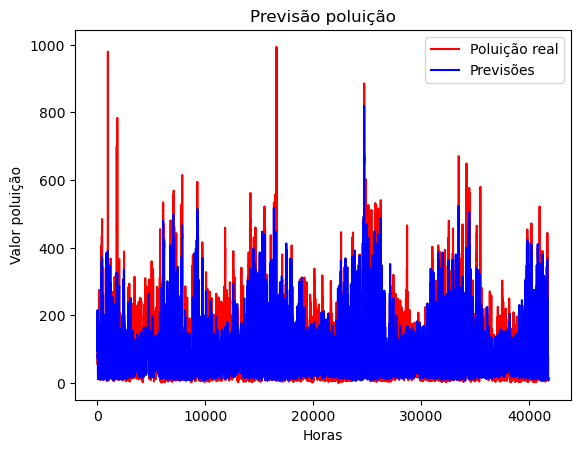

In [35]:
# Geração do gráfico. Será gerado um gráfico de barras porque temos muitos registros
plt.plot(poluicao, color = 'red', label = 'Poluição real')
plt.plot(previsoes, color = 'blue', label = 'Previsões')
plt.title('Previsão poluição')
plt.xlabel('Horas')
plt.ylabel('Valor poluição')
plt.legend()
plt.show()